# Proyecto: Sistema de recomendación de productos para clientes comerciales en empresa de consumo masivo 

### Integrantes:
- Jessica Salazar
- Camilo Umaña

### Librerias 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# =========================
# CARGA DE DATOS
# =========================

clientes = pd.read_csv("Clientes.csv",sep=";", encoding="latin1")
resumen = pd.read_csv("Resumen.csv", sep=";", encoding="latin1")


In [3]:
# =========================
# LIMPIEZA
# =========================

for col in ["Venta", "KG", "Ton"]:
    resumen[col] = (
        resumen[col]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    resumen[col] = pd.to_numeric(
        resumen[col],
        errors="coerce"
    )

In [4]:
# =========================
# INFORMACIÓN GENERAL
# =========================

print("="*50)
print("CLIENTES")
print("="*50)

print(clientes.shape)
print(clientes.info())
print(clientes.describe(include="all"))

print("\nValores nulos")
print(clientes.isnull().sum())

print("\nValores únicos")
print(clientes.nunique())

print("="*50)
print("RESUMEN")
print("="*50)

print(resumen.shape)
print(resumen.info())
print(resumen.describe())

print("\nValores nulos")
print(resumen.isnull().sum())

CLIENTES
(6316, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6316 entries, 0 to 6315
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Deudor                      6316 non-null   int64 
 1   Población                   6316 non-null   object
 2   Frecuencia de visita        6316 non-null   int64 
 3   Desde centro                6316 non-null   int64 
 4   Oficina de ventas           6316 non-null   object
 5   Denominación Gr#Clientes 5  6316 non-null   object
 6   Denominación Gr#Clientes 4  6316 non-null   object
dtypes: int64(3), object(4)
memory usage: 345.5+ KB
None
              Deudor    Población  Frecuencia de visita  Desde centro  \
count   6.316000e+03         6316           6316.000000   6316.000000   
unique           NaN          474                   NaN           NaN   
top              NaN  BOGOTÁ D.C.                   NaN           NaN   
freq             NaN  

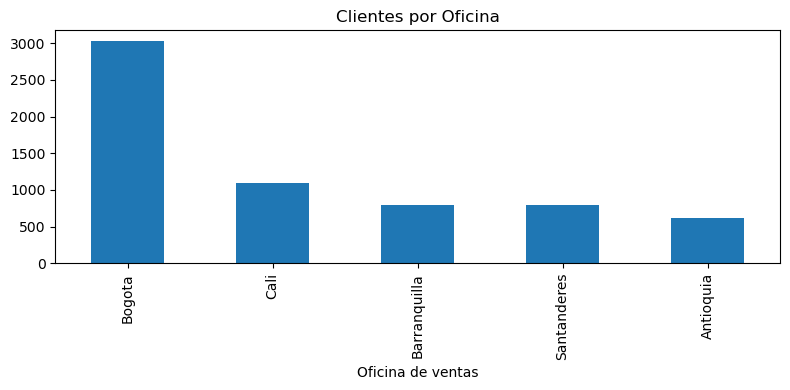

In [5]:
# =========================
# CLIENTES POR OFICINA
# =========================

clientes["Oficina de ventas"] \
    .value_counts() \
    .plot(
        kind="bar",
        figsize=(8,4),
        title="Clientes por Oficina"
    )

plt.tight_layout()
plt.show()


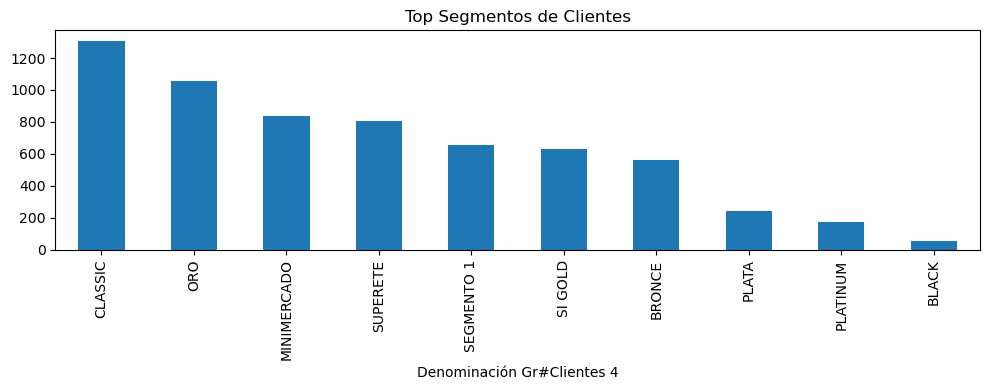

In [6]:
# =========================
# SEGMENTACIÓN CLIENTES
# =========================

clientes["Denominación Gr#Clientes 4"] \
    .value_counts() \
    .head(10) \
    .plot(
        kind="bar",
        figsize=(10,4),
        title="Top Segmentos de Clientes"
    )

plt.tight_layout()
plt.show()

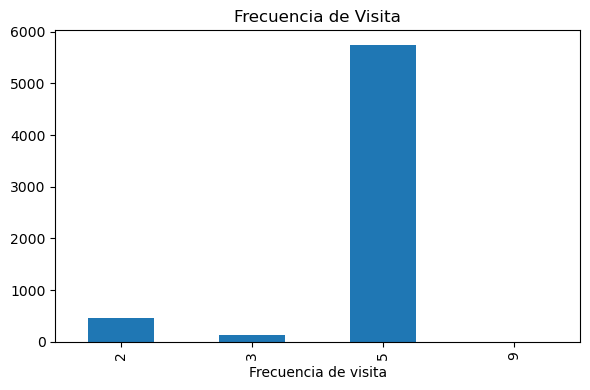

In [7]:
# =========================
# DISTRIBUCIÓN FRECUENCIA
# =========================

clientes["Frecuencia de visita"] \
    .value_counts() \
    .sort_index() \
    .plot(
        kind="bar",
        figsize=(6,4),
        title="Frecuencia de Visita"
    )

plt.tight_layout()
plt.show()

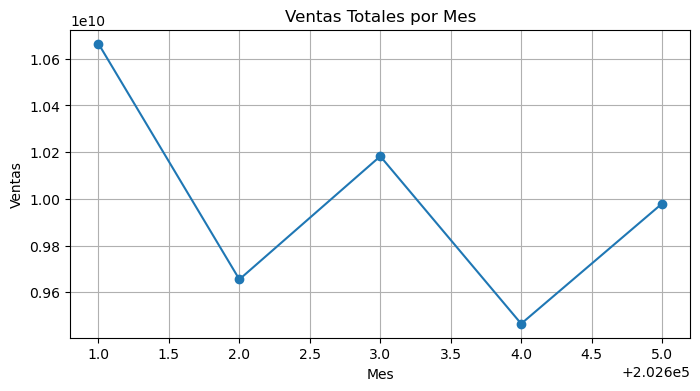

In [9]:
# =========================
# VENTAS POR MES
# =========================

ventas_mes = resumen.groupby(
    "Mes"
)["Venta"].sum()

ventas_mes.plot(
    marker="o",
    figsize=(8,4),
    title="Ventas Totales por Mes"
)

plt.ylabel("Ventas")
plt.grid(True)

plt.show()

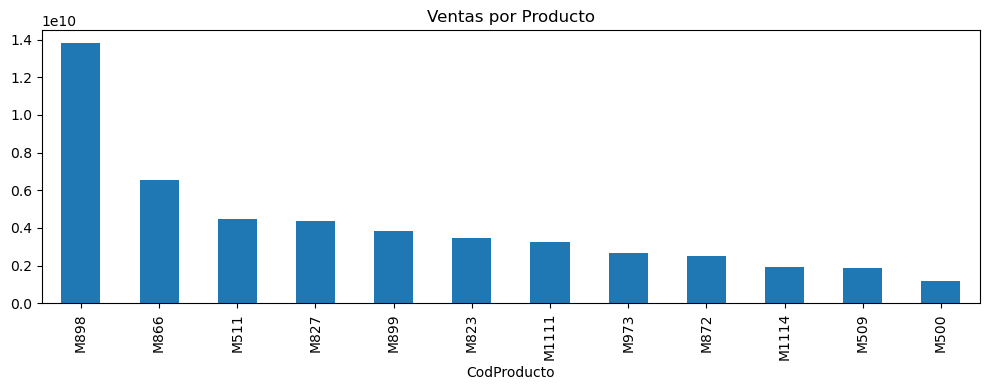

In [10]:
# =========================
# PRODUCTOS MÁS VENDIDOS
# =========================

productos = resumen.groupby(
    "CodProducto"
)["Venta"].sum().sort_values(
    ascending=False
)

productos.plot(
    kind="bar",
    figsize=(10,4),
    title="Ventas por Producto"
)

plt.tight_layout()
plt.show()

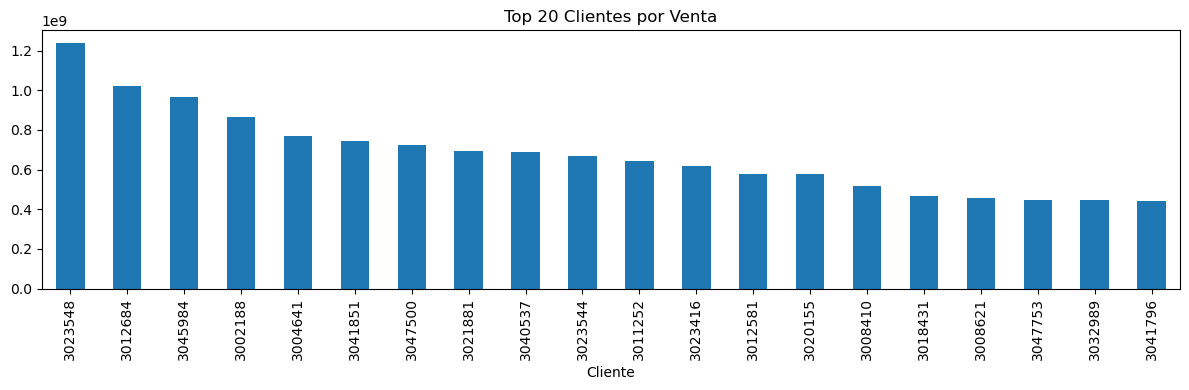

In [11]:
# =========================
# TOP CLIENTES
# =========================

top_clientes = resumen.groupby(
    "Cliente"
)["Venta"].sum().sort_values(
    ascending=False
).head(20)

top_clientes.plot(
    kind="bar",
    figsize=(12,4),
    title="Top 20 Clientes por Venta"
)

plt.tight_layout()
plt.show()

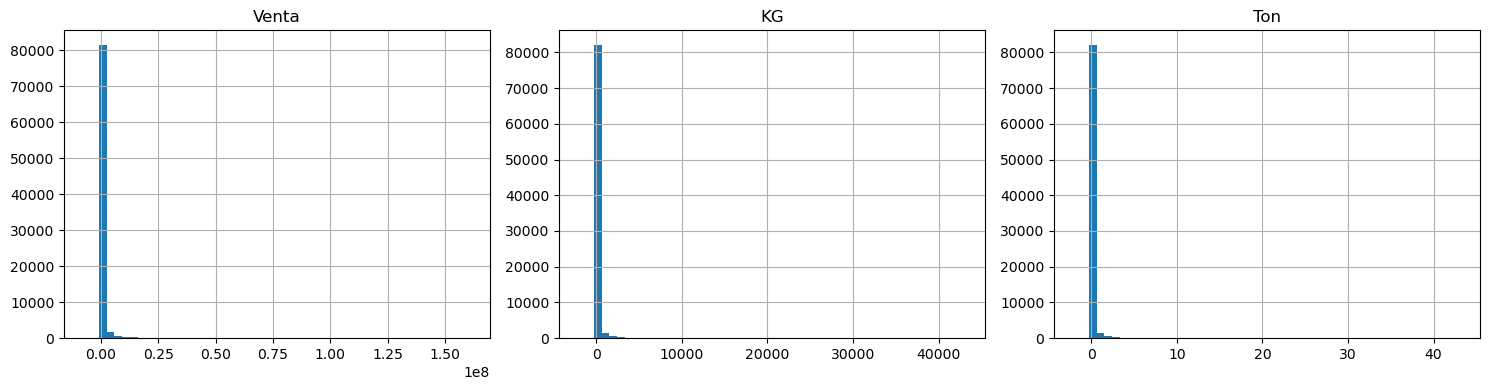

In [12]:
# =========================
# HISTOGRAMAS
# =========================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

resumen["Venta"].hist(
    bins=50,
    ax=ax[0]
)

ax[0].set_title("Venta")

resumen["KG"].hist(
    bins=50,
    ax=ax[1]
)

ax[1].set_title("KG")

resumen["Ton"].hist(
    bins=50,
    ax=ax[2]
)

ax[2].set_title("Ton")

plt.tight_layout()
plt.show()

In [13]:
# =========================
# INTEGRACIÓN
# =========================

base_modelo = resumen.merge(
    clientes,
    left_on="Cliente",
    right_on="Deudor",
    how="left"
)

print(base_modelo.shape)

print(
    base_modelo.head()
)

(84676, 13)
      Mes  Cliente CodProducto      Venta     KG     Ton   Deudor  \
0  202601  3046734        M898  101785.31   25.0  0.0250  3046734   
1  202601  3047625        M827   21111.04    2.8  0.0028  3047625   
2  202601  3046539       M1111  888925.05  135.0  0.1350  3046539   
3  202601  3008944        M827   61523.64    8.4  0.0084  3008944   
4  202601  3045006        M823  189999.36   25.2  0.0252  3045006   

       Población  Frecuencia de visita  Desde centro Oficina de ventas  \
0         BOJACÁ                     5          6038            Bogota   
1     FACATATIVÁ                     5          6038            Bogota   
2    BOGOTÁ D.C.                     5          6038            Bogota   
3   PUERTO LÓPEZ                     5          6038            Bogota   
4  VILLAVICENCIO                     5          6038            Bogota   

  Denominación Gr#Clientes 5 Denominación Gr#Clientes 4  
0                 MAYORISTAS                     BRONCE  
1           

#### Ventas por oficina de ventas

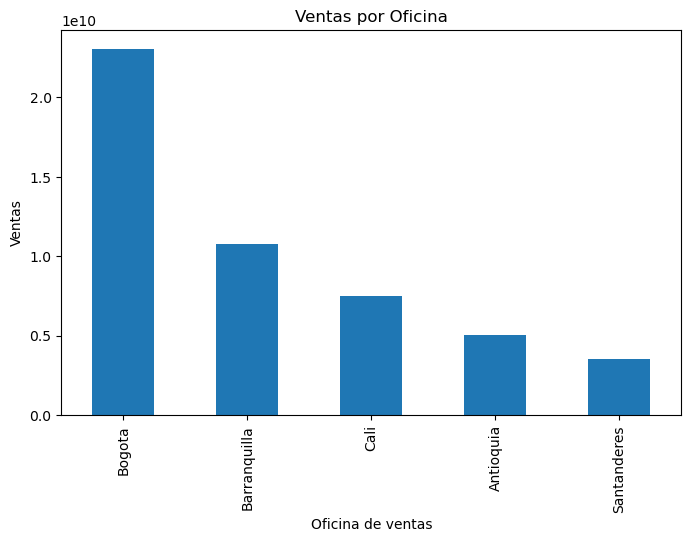

In [14]:
base = resumen.merge(
    clientes,
    left_on="Cliente",
    right_on="Deudor",
    how="left"
)

ventas_oficina = (
    base.groupby("Oficina de ventas")["Venta"]
    .sum()
    .sort_values(ascending=False)
)

ventas_oficina.plot(kind="bar", figsize=(8,5))
plt.title("Ventas por Oficina")
plt.ylabel("Ventas")
plt.show()

### Evolución mensual de ventas

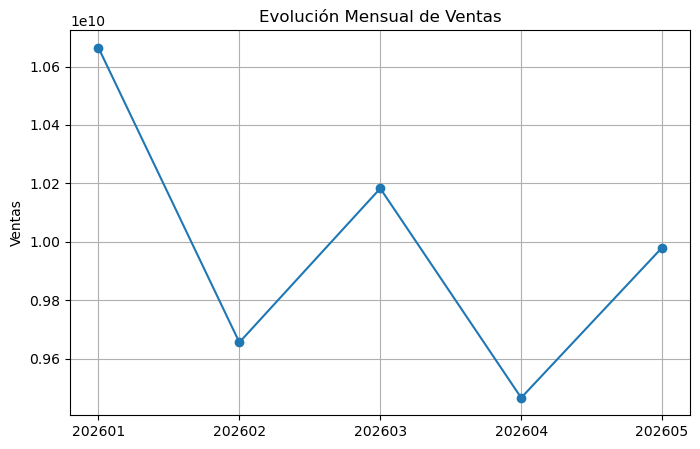

In [15]:
ventas_mes = resumen.groupby("Mes")["Venta"].sum()

plt.figure(figsize=(8,5))
plt.plot(ventas_mes.index.astype(str),
         ventas_mes.values,
         marker="o")

plt.title("Evolución Mensual de Ventas")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

### Participación de las oficinas

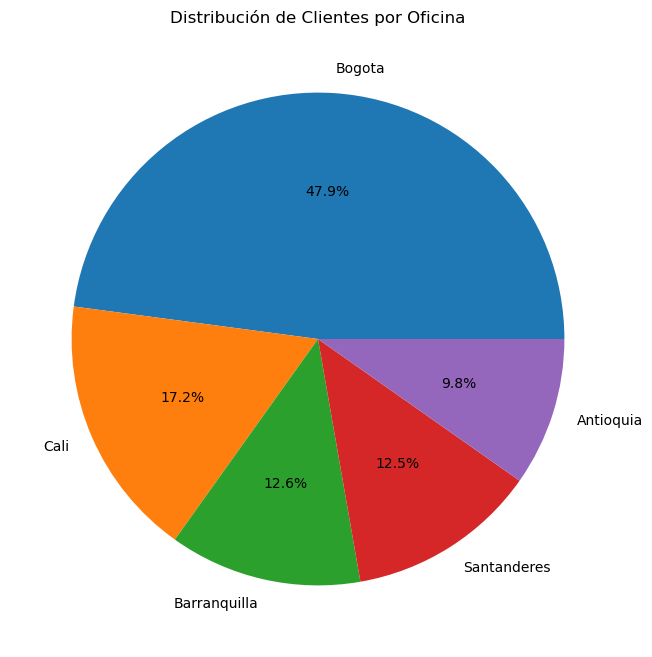

In [16]:
clientes["Oficina de ventas"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Distribución de Clientes por Oficina")
plt.ylabel("")
plt.show()

### Top 10 productos más vendidos

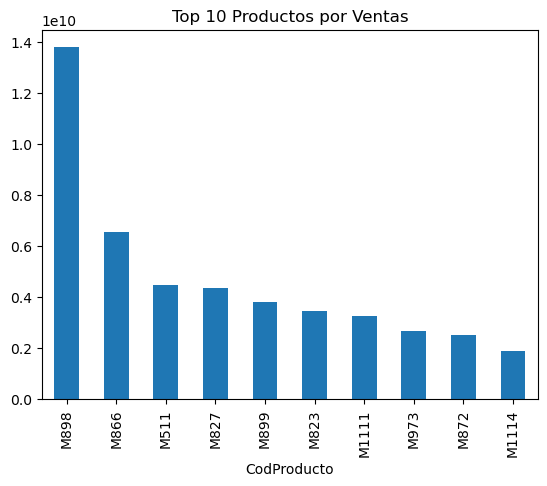

In [17]:
top_productos = (
    resumen.groupby("CodProducto")["Venta"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_productos.plot(kind="bar")
plt.title("Top 10 Productos por Ventas")
plt.show()

### Distribución de ventas por cliente

C:\Users\jcuma\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


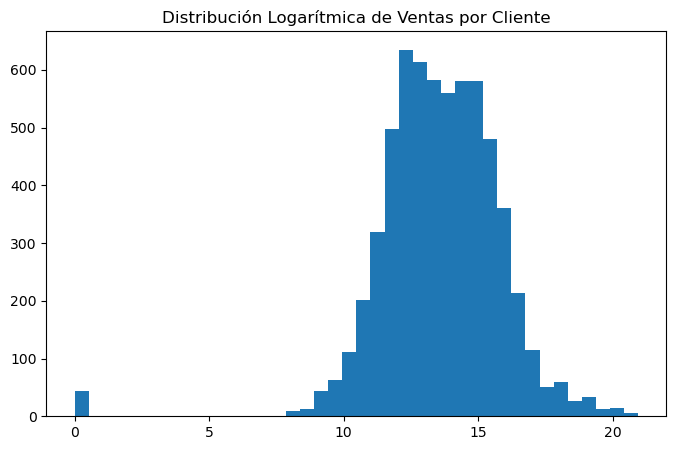

In [18]:
ventas_cliente = (
    resumen.groupby("Cliente")["Venta"]
    .sum()
)

plt.figure(figsize=(8,5))
plt.hist(np.log1p(ventas_cliente), bins=40)
plt.title("Distribución Logarítmica de Ventas por Cliente")
plt.show()

### Heatmap de ventas por mes y producto

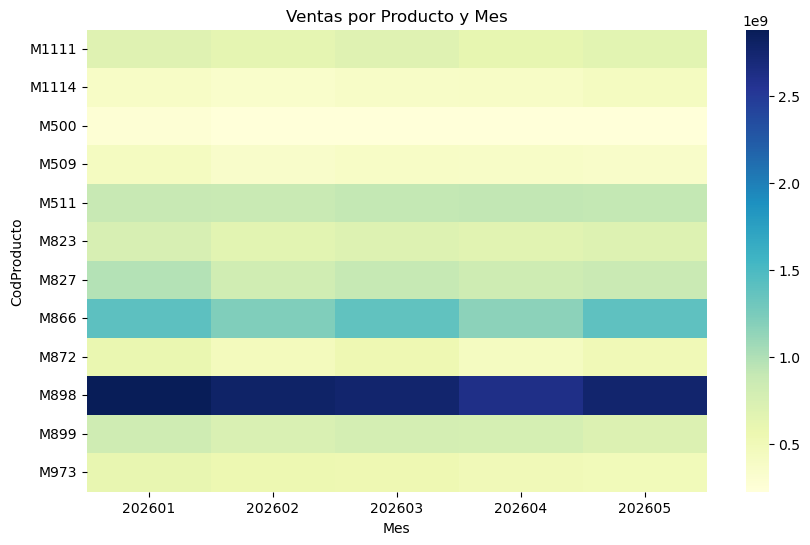

In [19]:
tabla = pd.pivot_table(
    resumen,
    values="Venta",
    index="CodProducto",
    columns="Mes",
    aggfunc="sum"
)

import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(tabla, cmap="YlGnBu")
plt.title("Ventas por Producto y Mes")
plt.show()

### Clientes más importantes (Pareto 80/20)

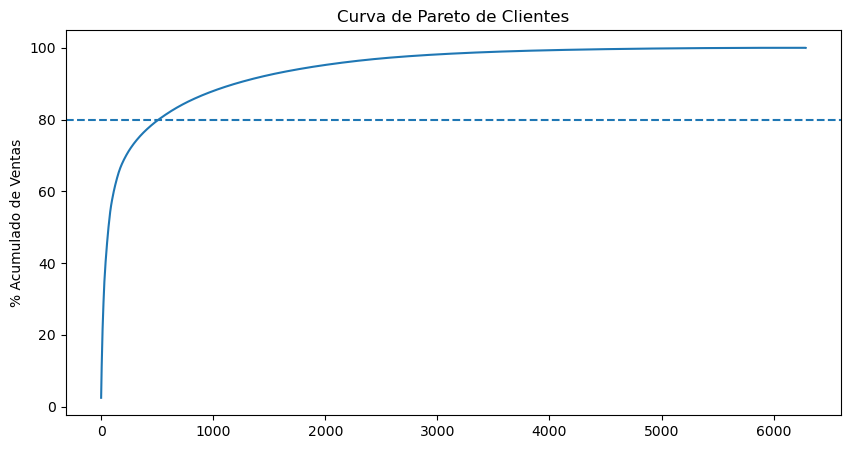

In [20]:
ventas_cliente = (
    resumen.groupby("Cliente")["Venta"]
    .sum()
    .sort_values(ascending=False)
)

acum = ventas_cliente.cumsum()/ventas_cliente.sum()*100

plt.figure(figsize=(10,5))
plt.plot(acum.values)
plt.axhline(80, linestyle="--")
plt.title("Curva de Pareto de Clientes")
plt.ylabel("% Acumulado de Ventas")
plt.show()

### Frecuencia de visita vs ventas

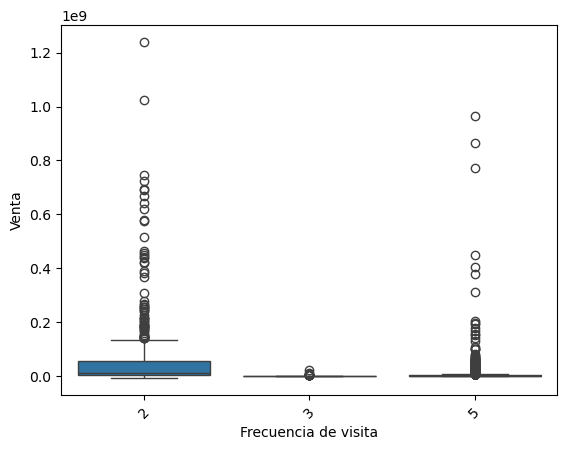

In [21]:
ventas_cliente = (
    resumen.groupby("Cliente")["Venta"]
    .sum()
    .reset_index()
)

base_freq = ventas_cliente.merge(
    clientes,
    left_on="Cliente",
    right_on="Deudor"
)

sns.boxplot(
    data=base_freq,
    x="Frecuencia de visita",
    y="Venta"
)

plt.xticks(rotation=45)
plt.show()

### Correlación en Resumen

In [24]:
for col in ['Venta', 'KG', 'Ton']:
    resumen[col] = (
        resumen[col]
        .astype(str)
        .str.replace('.', '', regex=False)   # separador de miles
        .str.replace(',', '.', regex=False)  # decimal
    )

    resumen[col] = pd.to_numeric(
        resumen[col],
        errors='coerce'
    )
print(resumen[['Venta','KG','Ton']].dtypes)

Venta    float64
KG       float64
Ton      float64
dtype: object


In [25]:
corr = resumen[['Venta', 'KG', 'Ton']].corr()

print(corr)

          Venta        KG       Ton
Venta  1.000000  0.965197  0.965197
KG     0.965197  1.000000  1.000000
Ton    0.965197  1.000000  1.000000


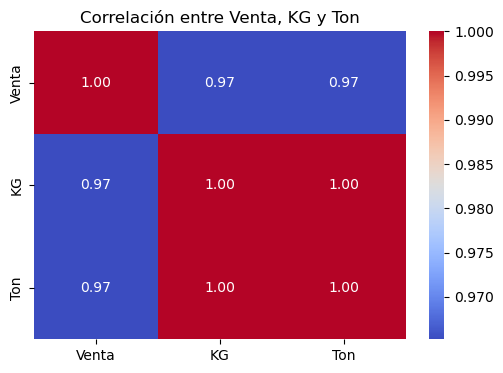

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlación entre Venta, KG y Ton')
plt.show()

### Correlación después de agregar variables de negocio

In [27]:
ventas_cliente = (
    resumen.groupby("Cliente")
    .agg({
        "Venta":"sum",
        "KG":"sum",
        "Ton":"sum",
        "Mes":"count"
    })
    .rename(columns={"Mes":"Num_Transacciones"})
    .reset_index()
)

corr = ventas_cliente[
    ["Venta","KG","Ton","Num_Transacciones"]
].corr()

print(corr)

                      Venta        KG       Ton  Num_Transacciones
Venta              1.000000  0.993728  0.993728           0.420813
KG                 0.993728  1.000000  1.000000           0.412630
Ton                0.993728  1.000000  1.000000           0.412630
Num_Transacciones  0.420813  0.412630  0.412630           1.000000


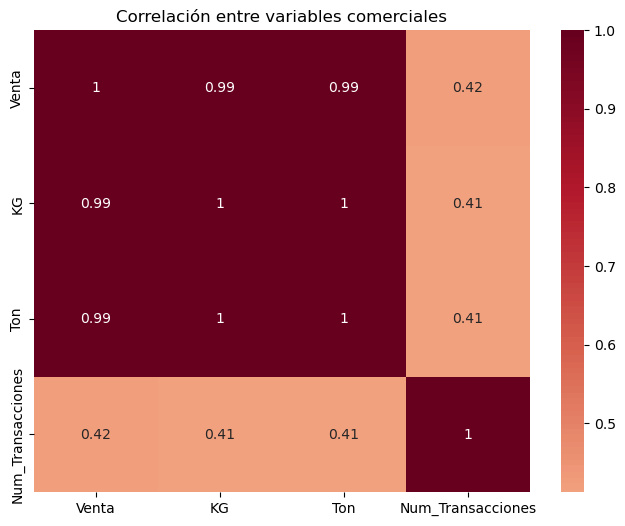

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    center=0
)

plt.title("Correlación entre variables comerciales")
plt.show()